# Editing analysis



In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

# SAV analysis

In [2]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE3 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool3.zip')
SAV_ABE3 = pd.merge(SAV_ABE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE3 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool3.zip')
SAV_CBE3 =  pd.merge(SAV_CBE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

In [3]:
#define the possible codon and SAV substitutions
CDK_info = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']

CDK_info = CDK_info[CDK_info['Gene'].isin(genes)].reset_index(drop=True)

aas = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', '*']


var_holder_possible = []
cod_holder_possible = []

for gene in genes:
    pp = CDK_info.loc[CDK_info['Gene']==gene, 'Protein'].values[0]
    var_possible = []
    cod_possible = []

    for kk, val in enumerate(pp):
        orig_aa = val
        codon_loc = int(kk+1) #account for off-by-one indexing
        cod_possible.append(codon_loc)

        for aa in aas:
            if aa!=orig_aa:
                var_possible.append(f'{orig_aa}{codon_loc}{aa}')

    var_holder_possible.append(var_possible)
    cod_holder_possible.append(cod_possible)


variants_dict_possible = dict(zip(genes, var_holder_possible))
cod_dict_possible = dict(zip(genes, cod_holder_possible))

In [4]:
def subset_calc_var(gene1, ABE, CBE, variants_dict_possible, edit_cutoff):

    list1 = CBE[CBE['Gene']==gene1]
    list2 = ABE[ABE['Gene']==gene1]
    list3 = variants_dict_possible[gene1]

    list1 = list1[list1['%Reads']>=edit_cutoff]['HGVSp']
    list2 = list2[list2['%Reads']>=edit_cutoff]['HGVSp']

    set1 = set(list1)
    set2 = set(list2)
    set3 = set(list3)

    subset1 = len(set1 - set2 - set3)  # Only in set1
    subset2 = len(set2 - set1 - set3)  # Only in set2
    subset3 = len(set3 - set1 - set2)  # Only in set3
    subset12 = len(set1.intersection(set2) - set3)  # In set1 and set2, but not set3
    subset13 = len(set1.intersection(set3) - set2)  # In set1 and set3, but not set2
    subset23 = len(set2.intersection(set3) - set1)  # In set2 and set3, but not set1
    subset123 = len(set1.intersection(set2).intersection(set3))  # In all three sets

    subsets = (subset1, subset2, subset12, subset3, subset13, subset23, subset123)

    return subsets

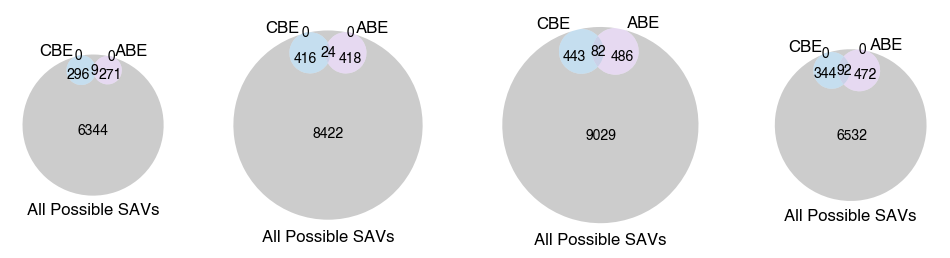

In [124]:

from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK7 = subset_calc_var('CDK7', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK8 = subset_calc_var('CDK8', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK19 = subset_calc_var('CDK19', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)
subset_CDK9 = subset_calc_var('CDK9', SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)


ratios = [sum(v) for v in [subset_CDK7, subset_CDK8, subset_CDK19, subset_CDK9]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,4,figsize=(12,3), width_ratios=norm)


c = venn3(subsets=subset_CDK7, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK8, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK19, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c4 = venn3(subsets=subset_CDK9, ax=ax[3], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool1_{edit_cutoff}.pdf', transparent=True)

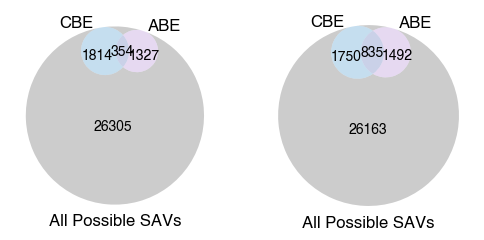

In [125]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK12 = subset_calc_var('CDK12', SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)
subset_CDK13 = subset_calc_var('CDK13', SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)


ratios = [sum(v) for v in [subset_CDK12, subset_CDK13]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,2,figsize=(6,3), width_ratios=norm)

c = venn3(subsets=subset_CDK12, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK13, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool2_{edit_cutoff}.pdf', transparent=True)

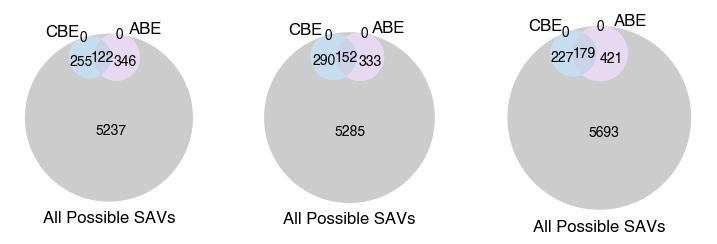

In [ ]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK2 = subset_calc_var('CDK2', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)
subset_CDK4 = subset_calc_var('CDK4', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)
subset_CDK6 = subset_calc_var('CDK6', SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)

ratios = [sum(v) for v in [subset_CDK2, subset_CDK4, subset_CDK6]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,3,figsize=(9,3), width_ratios=norm)

c = venn3(subsets=subset_CDK2, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK4, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK6, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible SAVs'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_vars_subpool2_{edit_cutoff}.pdf', transparent=True)
#fig.savefig('../../figures/subpool3_vars_editing.pdf', transparent=True)

In [5]:

def codon_calc(df):
    """ 
    Function for converting SAV df to sorting mutation rate by Codon for each gRNA
    i.e. sum %Reads by Codon for a given gRNA
    output excludes WT (but % remain accurate)
    """
    
    new = []
    for i in np.unique(df['gRNA_id']):
        sub = df[df['gRNA_id']==i][['Codon', '%Reads']].groupby('Codon').sum().reset_index()
        sub['gRNA_id'] = i
        new.append(sub)

    n_cod = pd.concat(new)
    n_cod = pd.merge(n_cod, library[['gRNA_id', 'Gene']], on='gRNA_id')

    n_cod = n_cod[n_cod['Codon']!='WT']
    n_cod['Codon'] = [int(i) for i in n_cod['Codon']]

    return n_cod

cod_ABE1 = codon_calc(SAV_ABE1)
cod_ABE2 = codon_calc(SAV_ABE2)
cod_ABE3 = codon_calc(SAV_ABE3)

cod_CBE1 = codon_calc(SAV_CBE1)
cod_CBE2 = codon_calc(SAV_CBE2)
cod_CBE3 = codon_calc(SAV_CBE3)

In [6]:

def subset_calc_cod(gene1, ABE, CBE, cod_dict_possible, edit_cutoff):
    list1 = CBE[CBE['Gene']==gene1]
    list2 = ABE[ABE['Gene']==gene1]

    list1 = list1[list1['%Reads']>=edit_cutoff]['Codon']
    list2 = list2[list2['%Reads']>=edit_cutoff]['Codon']

    list3 = cod_dict_possible[gene1]

    set1 = set(list1)
    set2 = set(list2)
    set3 = set(list3)

    subset1 = len(set1 - set2 - set3)  # Only in set1
    subset2 = len(set2 - set1 - set3)  # Only in set2
    subset3 = len(set3 - set1 - set2)  # Only in set3
    subset12 = len(set1.intersection(set2) - set3)  # In set1 and set2, but not set3
    subset13 = len(set1.intersection(set3) - set2)  # In set1 and set3, but not set2
    subset23 = len(set2.intersection(set3) - set1)  # In set2 and set3, but not set1
    subset123 = len(set1.intersection(set2).intersection(set3))  # In all three sets

    subsets = (subset1, subset2, subset12, subset3, subset13, subset23, subset123)

    return subsets

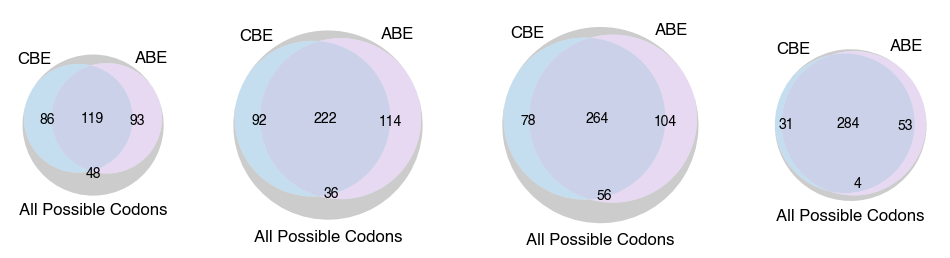

In [ ]:
edit_cutoff = 10

subset_CDK7 = subset_calc_cod('CDK7', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK8 = subset_calc_cod('CDK8', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK19 = subset_calc_cod('CDK19', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
subset_CDK9 = subset_calc_cod('CDK9', cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)


from matplotlib_venn import venn3

ratios = [sum(v) for v in [subset_CDK7, subset_CDK8, subset_CDK19, subset_CDK9]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,4,figsize=(12,3), width_ratios=norm)


c = venn3(subsets=subset_CDK7, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK8, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK19, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c4 = venn3(subsets=subset_CDK9, ax=ax[3], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig(f'../../figures/venn_codon_subpool1_{edit_cutoff}.pdf', transparent=True)

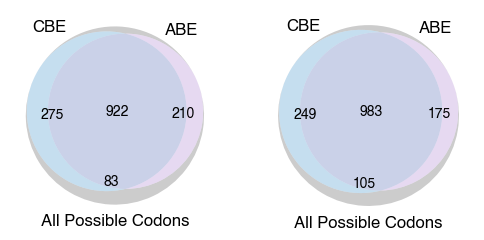

In [69]:
edit_cutoff = 10

subset_CDK12 = subset_calc_cod('CDK12', cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)
subset_CDK13 = subset_calc_cod('CDK13', cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)


from matplotlib_venn import venn3

ratios = [sum(v) for v in [subset_CDK12, subset_CDK13]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,2,figsize=(6,3), width_ratios=norm)

c = venn3(subsets=subset_CDK12, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK13, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))


#fig.savefig(f'../../figures/venn_codon_cdk12_13_{edit_cutoff}.pdf', transparent=True)

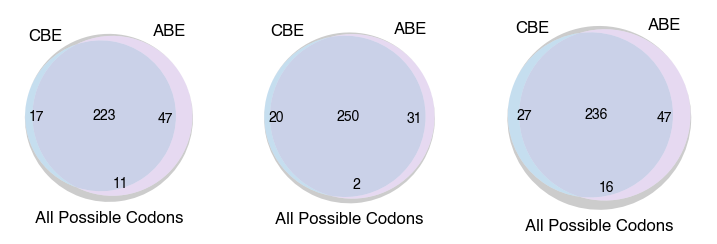

In [ ]:
from matplotlib_venn import venn3


edit_cutoff = 10
subset_CDK2 = subset_calc_cod('CDK2', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
subset_CDK4 = subset_calc_cod('CDK4', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
subset_CDK6 = subset_calc_cod('CDK6', cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)

ratios = [sum(v) for v in [subset_CDK2, subset_CDK4, subset_CDK6]]
norm = [n / sum(ratios) for n in ratios]

fig, ax = plt.subplots(1,3,figsize=(9,3), width_ratios=norm)

c = venn3(subsets=subset_CDK2, ax=ax[0], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c2 = venn3(subsets=subset_CDK4, ax=ax[1], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))
c3 = venn3(subsets=subset_CDK6, ax=ax[2], set_labels=('CBE', 'ABE', 'All Possible Codons'), set_colors = ('tab:blue', 'tab:purple', 'grey'))

#fig.savefig('../../figures/subpool3_aa_editing.pdf', transparent=True)

In [137]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']


var_cols = [f'{gene}_total_vars' for gene in genes]
var_cols_CBE = [f'{gene}_CBE_vars' for gene in genes]
var_cols_ABE = [f'{gene}_ABE_vars' for gene in genes]

cod_cols = [f'{gene}_total_codons' for gene in genes]
cod_cols_CBE = [f'{gene}_CBE_codons' for gene in genes]
cod_cols_ABE = [f'{gene}_ABE_codons' for gene in genes]

cols = ['editing_cutoff'] + var_cols + var_cols_CBE + var_cols_ABE + cod_cols + cod_cols_ABE + cod_cols_CBE

plotting_df = pd.DataFrame(dict(zip(cols, [list(range(0,101))] + [np.zeros(101) for i in range(6*3*2)])))
plotting_df

,editing_cutoff,CDK7_total_vars,CDK8_total_vars,CDK19_total_vars,CDK9_total_vars,CDK12_total_vars,CDK13_total_vars,CDK2_total_vars,CDK4_total_vars,CDK6_total_vars,...,CDK6_ABE_vars,CDK7_total_codons,CDK8_total_codons,CDK19_total_codons,CDK9_total_codons,CDK12_total_codons,CDK13_total_codons,CDK2_total_codons,CDK4_total_codons,CDK6_total_codons
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# And then plot as a function of editing cutoff

In [7]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']


var_cols = [f'{gene}_total_vars' for gene in genes]
var_cols_CBE = [f'{gene}_CBE_vars' for gene in genes]
var_cols_ABE = [f'{gene}_ABE_vars' for gene in genes]

cod_cols = [f'{gene}_total_codons' for gene in genes]
cod_cols_CBE = [f'{gene}_CBE_codons' for gene in genes]
cod_cols_ABE = [f'{gene}_ABE_codons' for gene in genes]

cols = ['editing_cutoff'] + var_cols + var_cols_CBE + var_cols_ABE + cod_cols + cod_cols_ABE + cod_cols_CBE

plotting_df = pd.DataFrame(dict(zip(cols, [list(range(0,101))] + [np.zeros(101) for i in range(9*3*2)])))

for edit_cutoff in range(0,101):

    for gene in genes:

        if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
            codons = subset_calc_cod(gene, cod_ABE1, cod_CBE1, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE1, SAV_CBE1, variants_dict_possible, edit_cutoff)

        elif gene in ['CDK12', 'CDK13']:
            codons = subset_calc_cod(gene, cod_ABE2, cod_CBE2, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE2, SAV_CBE2, variants_dict_possible, edit_cutoff)

        elif gene in ['CDK2', 'CDK4', 'CDK6']:
            codons = subset_calc_cod(gene, cod_ABE3, cod_CBE3, cod_dict_possible, edit_cutoff)
            vars = subset_calc_var(gene, SAV_ABE3, SAV_CBE3, variants_dict_possible, edit_cutoff)



        #add var info
        ABE_subset = vars[5]
        CBE_subset = vars[4]
        shared = vars[6]
        missing = vars[3]

        total_inc = ABE_subset + CBE_subset + shared
        total = ABE_subset+ CBE_subset + shared + missing
        frac = 100*(total_inc/total)

        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_total_vars'] = frac
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_ABE_vars'] = 100*((ABE_subset+shared)/total)
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_CBE_vars'] = 100*((CBE_subset+shared)/total)

        #and add cod info
        ABE_subset = codons[5]
        CBE_subset = codons[4]
        shared = codons[6]
        missing = codons[3]

        total_inc = ABE_subset + CBE_subset + shared
        total = ABE_subset+ CBE_subset + shared + missing
        frac = 100*(total_inc/total)

        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_total_codons'] = frac
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_ABE_codons'] = 100*((ABE_subset+shared)/total)
        plotting_df.loc[plotting_df['editing_cutoff']==edit_cutoff, f'{gene}_CBE_codons'] = 100*((CBE_subset+shared)/total)




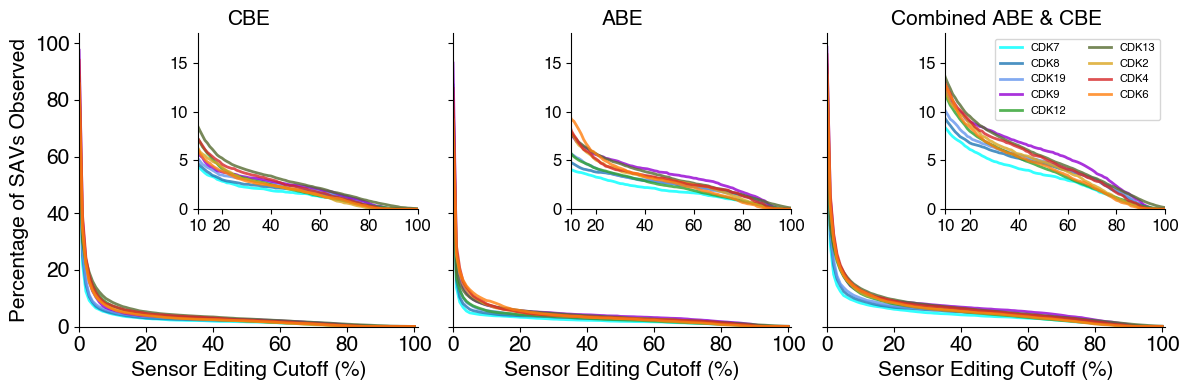

In [9]:


fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True, sharex=True)
ins1 = ax[0].inset_axes([0.35,.4,0.65,0.6])
ins2 = ax[1].inset_axes([0.35,.4,0.65,0.6])
ins3 = ax[2].inset_axes([0.35,.4,0.65,0.6])

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])

#inset parameters
ins1.spines[['right', 'top']].set_visible(False)
ins1.tick_params(axis='both', which='major', labelsize=12)
ins1.set_xlim(10,100)
ins1.set_ylim(0,18)
ins2.spines[['right', 'top']].set_visible(False)
ins2.tick_params(axis='both', which='major', labelsize=12)
ins2.set_xlim(10,100)
ins2.set_ylim(0,18)
ins3.spines[['right', 'top']].set_visible(False)
ins3.tick_params(axis='both', which='major', labelsize=12)
ins3.set_xlim(10,100)
ins3.set_ylim(0,18)


ins1.set_xticks([10,20,40,60,80,100])
ins2.set_xticks([10,20,40,60,80,100])
ins3.set_xticks([10,20,40,60,80,100])


#other params
ax[0].set_ylabel('Percentage of SAVs Observed', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

ax[2].legend(fontsize=8, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
#fig.savefig(f'../../figures/vars_by_edit_cutoff_v2.pdf', transparent=True)

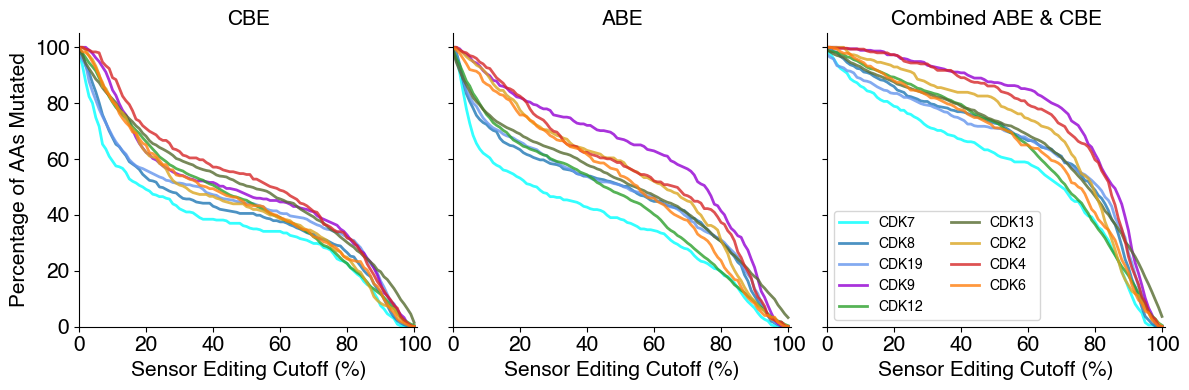

In [ ]:


fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True, sharex=True)


color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_codons'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_codons'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_codons'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])



#other params
ax[0].set_ylabel('Percentage of AAs Mutated', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

ax[2].legend(fontsize=10, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
#fig.savefig(f'../../figures/codons_by_edit_cutoff_v2.pdf', transparent=True)

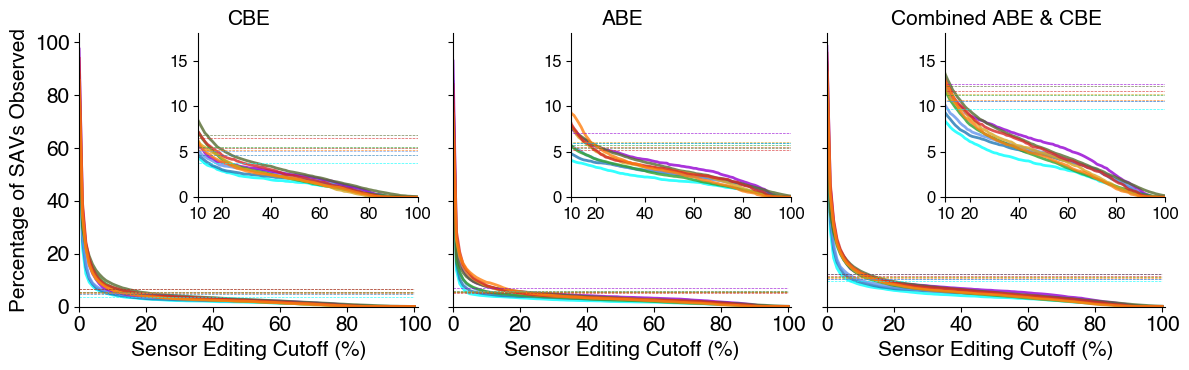

In [ ]:


fig, ax = plt.subplots(1,3, figsize=(12,3.8), sharey=True, sharex=True)
ins1 = ax[0].inset_axes([0.35,.4,0.65,0.6])
ins2 = ax[1].inset_axes([0.35,.4,0.65,0.6])
ins3 = ax[2].inset_axes([0.35,.4,0.65,0.6])

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])

for gene in genes:
    cdk2 = pd.read_csv(f'../../source_data/01_library_generation_files/edit_libraries/{gene}_edits.csv')
    cdk2 = cdk2.dropna(subset='HGVSp')

    coverage = 100*(len(np.unique(cdk2['HGVSp']))/len(variants_dict_possible[f'{gene}']))

    abe_coverage = 100*(len(np.unique(cdk2[cdk2['Editor']=='ABE']['HGVSp']))/len(variants_dict_possible[f'{gene}']))
    cbe_coverage = 100*(len(np.unique(cdk2[cdk2['Editor']=='CBE']['HGVSp']))/len(variants_dict_possible[f'{gene}']))

    ax[0].plot([0,100],[cbe_coverage, cbe_coverage],  linewidth=.5,  alpha=.8, c=color_dict[gene], linestyle='dashed')
    ax[1].plot([0,100],[abe_coverage, abe_coverage], linewidth=.5,  alpha=.8, c=color_dict[gene], linestyle='dashed')
    ax[2].plot([0,100],[coverage, coverage],  linewidth=.5, alpha=.8, c=color_dict[gene], linestyle='dashed')

    ins1.plot([0,100],[cbe_coverage, cbe_coverage],  linewidth=.5,  alpha=.8, c=color_dict[gene], linestyle='dashed')
    ins2.plot([0,100],[abe_coverage, abe_coverage], linewidth=.5,  alpha=.8, c=color_dict[gene], linestyle='dashed')
    ins3.plot([0,100],[coverage, coverage],  linewidth=.5, alpha=.8, c=color_dict[gene], linestyle='dashed')

#inset parameters
ins1.spines[['right', 'top']].set_visible(False)
ins1.tick_params(axis='both', which='major', labelsize=12)
ins1.set_xlim(10,100)
ins1.set_ylim(0,18)
ins2.spines[['right', 'top']].set_visible(False)
ins2.tick_params(axis='both', which='major', labelsize=12)
ins2.set_xlim(10,100)
ins2.set_ylim(0,18)
ins3.spines[['right', 'top']].set_visible(False)
ins3.tick_params(axis='both', which='major', labelsize=12)
ins3.set_xlim(10,100)
ins3.set_ylim(0,18)


ins1.set_xticks([10,20,40,60,80,100])
ins2.set_xticks([10,20,40,60,80,100])
ins3.set_xticks([10,20,40,60,80,100])


#other params
ax[0].set_ylabel('Percentage of SAVs Observed', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

#ax[2].legend(fontsize=8, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
#fig.savefig('../../figures/predicted_SAVS.pdf', transparent=True)

In [13]:
len(variants_dict_possible['CDK7'])

6920

In [10]:
cdk2

,gRNA_id,edit,Editor,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,...,CBE_amenable,HGVSp,potential_splice,Complex,MUT_AA,WT_AA,Codon,sensor_wt,sensor_alt,Gene
2,gRNA_5,TCGGC,ABE,TATTCAGCTCCGAGGTGTTC,7,92615148,92615167,TG,92615168,92615169,...,True,L323P,False,False,P,L,323.0,GCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCCTGAGG,GCCGCCCAGCCAGAACACCTCGGAGCCGAATACAGCCTGAGG,CDK6
3,gRNA_6,CGGCT,ABE,ATTCAGCTCCGAGGTGTTCT,7,92615149,92615168,GG,92615169,92615170,...,True,L323P,False,False,P,L,323.0,TGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCCTGAG,TGCCGCCCAGCCAGAACACCTCGGAGCCGAATACAGCCTGAG,CDK6
4,gRNA_8,TCCGG,ABE,AGCTCCGAGGTGTTCTGGCT,7,92615153,92615172,GG,92615173,92615174,...,True,S321P,False,False,P,S,321.0,CACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCC,CACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACAGCC,CDK6
5,gRNA_9,CCGGG,ABE,GCTCCGAGGTGTTCTGGCTG,7,92615154,92615173,GG,92615174,92615175,...,True,S321P,False,False,P,S,321.0,CCACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGC,CCACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACAGC,CDK6
6,gRNA_10,GGGGT,ABE,TCCGAGGTGTTCTGGCTGGG,7,92615156,92615175,CG,92615176,92615177,...,False,S321P,False,False,P,S,321.0,TCCCACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACA,TCCCACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACA,CDK6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2166,gRNA_501,CGCGT,CBE,TGCCGCGCTGACCAGCAGTA,1,92833305,92833286,CG,92833284,92833283,...,True,A9V,False,False,V,A,9.0,GCCACGCATTCGTACTGCTGGTCAGCGCGGCACAGGCCGTCC,GCCACGCATTCGTACTGCTGGTCAACGCGGCACAGGCCGTCC,CDK6
2167,gRNA_501,TGTGC,CBE,TGCCGCGCTGACCAGCAGTA,1,92833305,92833286,CG,92833284,92833283,...,True,R8C,False,False,C,R,8.0,GCCACGCATTCGTACTGCTGGTCAGCGCGGCACAGGCCGTCC,GCCACGCATTCGTACTGCTGGTCAGCACAGCACAGGCCGTCC,CDK6
2169,gRNA_501,CGTGT,CBE,TGCCGCGCTGACCAGCAGTA,1,92833305,92833286,CG,92833284,92833283,...,True,A9V,False,False,V,A,9.0,GCCACGCATTCGTACTGCTGGTCAGCGCGGCACAGGCCGTCC,GCCACGCATTCGTACTGCTGGTCAACACGGCACAGGCCGTCC,CDK6
2172,gRNA_502,GTGCT,CBE,CCTGTGCCGCGCTGACCAGC,1,92833309,92833290,AG,92833288,92833287,...,True,R8C,False,False,C,R,8.0,CGCATTCGTACTGCTGGTCAGCGCGGCACAGGCCGTCCTTCT,CGCATTCGTACTGCTGGTCAGCGCAGCACAGGCCGTCCTTCT,CDK6


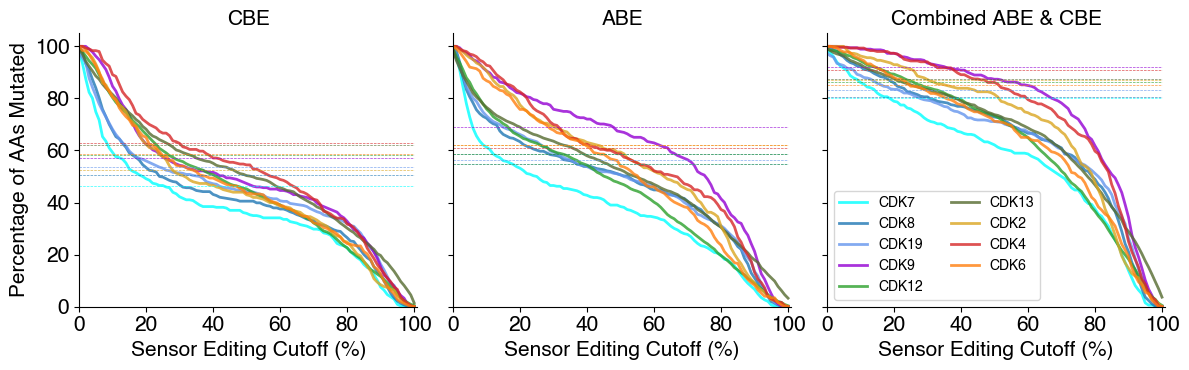

In [29]:


fig, ax = plt.subplots(1,3, figsize=(12,3.8), sharey=True, sharex=True)


color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}

for gene in genes:

    ax[0].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_codons'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins1.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_CBE_vars'], label=f'{gene} CBE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:

    ax[1].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_codons'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins2.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_ABE_vars'], label=f'{gene} ABE', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    ax[2].plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_codons'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])
    #ins3.plot(plotting_df['editing_cutoff'], plotting_df[f'{gene}_total_vars'], label=f'{gene}', linewidth=2, alpha=.8, c=color_dict[gene])


for gene in genes:
    cdk2 = pd.read_csv(f'../../source_data/01_library_generation_files/edit_libraries/{gene}_edits.csv')
    cdk2 = cdk2.dropna(subset='Codon')

    coverage = 100*(len(np.unique(cdk2['Codon']))/len(cod_dict_possible[f'{gene}']))

    abe_coverage = 100*(len(np.unique(cdk2[cdk2['Editor']=='ABE']['Codon']))/len(cod_dict_possible[f'{gene}']))
    cbe_coverage = 100*(len(np.unique(cdk2[cdk2['Editor']=='CBE']['Codon']))/len(cod_dict_possible[f'{gene}']))

    ax[0].plot([0,100],[cbe_coverage, cbe_coverage],  linewidth=.5,linestyle='dashed',  alpha=.8, c=color_dict[gene])
    ax[1].plot([0,100],[abe_coverage, abe_coverage], linewidth=.5,linestyle='dashed',  alpha=.8, c=color_dict[gene])


    ax[2].plot([0,100],[coverage, coverage],  linewidth=.5,linestyle='dashed', alpha=.8, c=color_dict[gene])


#other params
ax[0].set_ylabel('Percentage of AAs Mutated', fontsize=15)
ax[0].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[1].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)
ax[2].set_xlabel('Sensor Editing Cutoff (%)', fontsize=15)

ax[0].set_xlim(0,101)
ax[0].set_ylim(0,)

ax[0].set_xticks([0,20,40,60,80,100])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].tick_params(axis='both', which='major', labelsize=15)

ax[2].legend(fontsize=10, ncol=2)
ax[0].set_title('CBE', fontsize=15)
ax[1].set_title('ABE', fontsize=15)
ax[2].set_title('Combined ABE & CBE', fontsize=15)

fig.tight_layout()
fig.savefig('../../figures/predicted_codons.pdf', transparent=True)

In [157]:
genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9', 'CDK12', 'CDK13', 'CDK2', 'CDK4', 'CDK6']
for gene in genes:
    cdk2 = pd.read_csv(f'../../source_data/01_library_generation_files/edit_libraries/{gene}_edits.csv')

    cdk2 = cdk2.dropna(subset='Codon')

    coverage = 100*(len(np.unique(cdk2['Codon']))/len(cod_dict_possible[f'{gene}']))
    print(f'{gene} {coverage}')

CDK7 80.05780346820809
CDK8 80.60344827586206
CDK19 83.26693227091634
CDK9 91.93548387096774
CDK12 86.24161073825503
CDK13 87.56613756613757
CDK2 87.24832214765101
CDK4 90.75907590759076
CDK6 85.2760736196319


In [158]:
cdk2[cdk2['Editor']=='ABE']

,gRNA_id,edit,Editor,protospacer,exon,proto_start,proto_end,PAM,PAM_start,PAM_end,...,CBE_amenable,HGVSp,potential_splice,Complex,MUT_AA,WT_AA,Codon,sensor_wt,sensor_alt,Gene
2,gRNA_5,TCGGC,ABE,TATTCAGCTCCGAGGTGTTC,7,92615148,92615167,TG,92615168,92615169,...,True,L323P,False,False,P,L,323.0,GCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCCTGAGG,GCCGCCCAGCCAGAACACCTCGGAGCCGAATACAGCCTGAGG,CDK6
3,gRNA_6,CGGCT,ABE,ATTCAGCTCCGAGGTGTTCT,7,92615149,92615168,GG,92615169,92615170,...,True,L323P,False,False,P,L,323.0,TGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCCTGAG,TGCCGCCCAGCCAGAACACCTCGGAGCCGAATACAGCCTGAG,CDK6
4,gRNA_8,TCCGG,ABE,AGCTCCGAGGTGTTCTGGCT,7,92615153,92615172,GG,92615173,92615174,...,True,S321P,False,False,P,S,321.0,CACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGCC,CACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACAGCC,CDK6
5,gRNA_9,CCGGG,ABE,GCTCCGAGGTGTTCTGGCTG,7,92615154,92615173,GG,92615174,92615175,...,True,S321P,False,False,P,S,321.0,CCACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACAGC,CCACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACAGC,CDK6
6,gRNA_10,GGGGT,ABE,TCCGAGGTGTTCTGGCTGGG,7,92615156,92615175,CG,92615176,92615177,...,False,S321P,False,False,P,S,321.0,TCCCACCTGCCGCCCAGCCAGAACACCTCGGAGCTGAATACA,TCCCACCTGCCGCCCAGCCAGAACACCCCGGAGCTGAATACA,CDK6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1532,gRNA_506,AGGAG,ABE,TGGAGAAGGACGGCCTGTGC,1,92833322,92833303,CG,92833301,92833300,...,False,K3E,False,False,E,K,3.0,CTGGTCAGCGCGGCACAGGCCGTCCTTCTCCATGCCGCCTGG,CTGGTCAGCGCGGCACAGGCCGTCCTCCTCCATGCCGCCTGG,CDK6
1533,gRNA_506,AGAGG,ABE,TGGAGAAGGACGGCCTGTGC,1,92833322,92833303,CG,92833301,92833300,...,False,K3R,False,False,R,K,3.0,CTGGTCAGCGCGGCACAGGCCGTCCTTCTCCATGCCGCCTGG,CTGGTCAGCGCGGCACAGGCCGTCCCTCTCCATGCCGCCTGG,CDK6
1536,gRNA_506,AGGGG,ABE,TGGAGAAGGACGGCCTGTGC,1,92833322,92833303,CG,92833301,92833300,...,False,K3G,False,False,G,K,3.0,CTGGTCAGCGCGGCACAGGCCGTCCTTCTCCATGCCGCCTGG,CTGGTCAGCGCGGCACAGGCCGTCCCCCTCCATGCCGCCTGG,CDK6
1538,gRNA_507,TGGGG,ABE,GCATGGAGAAGGACGGCCTG,1,92833325,92833306,TG,92833304,92833303,...,False,E2G,False,False,G,E,2.0,GTCAGCGCGGCACAGGCCGTCCTTCTCCATGCCGCCTGGACG,GTCAGCGCGGCACAGGCCGTCCTTCCCCATGCCGCCTGGACG,CDK6


# Single vs. Compound Mutations

In [47]:
ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

ABE1['Gene'] = [i.split('_')[1] for i in ABE1['gRNA_id']]
CBE1['Gene'] = [i.split('_')[1] for i in CBE1['gRNA_id']]

ABE2['Gene'] = [i.split('_')[1] for i in ABE2['gRNA_id']]
CBE2['Gene'] = [i.split('_')[1] for i in CBE2['gRNA_id']]

ABE3['Gene'] = [i.split('_')[1] for i in ABE3['gRNA_id']]
CBE3['Gene'] = [i.split('_')[1] for i in CBE3['gRNA_id']]

In [134]:
min_edit = 10

ca = []
sa = []
cc = []
sc = []

combined_single = []
combined_double = []

for gene in genes:

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:

        sub_abe = ABE1[(ABE1['%Reads']>=min_edit) & (ABE1['HGVSp']!='WT')& (ABE1['Gene']==gene)]
        sub_cbe = CBE1[(CBE1['%Reads']>=min_edit) & (CBE1['HGVSp']!='WT')& (CBE1['Gene']==gene)]

    elif gene in ['CDK12', 'CDK13']:
        sub_abe = ABE2[(ABE2['%Reads']>=min_edit) & (ABE2['HGVSp']!='WT')& (ABE2['Gene']==gene)]
        sub_cbe = CBE2[(CBE2['%Reads']>=min_edit) & (CBE2['HGVSp']!='WT')& (CBE2['Gene']==gene)]

    elif gene in ['CDK2', 'CDK4', 'CDK6']:
        
        sub_abe = ABE3[(ABE3['%Reads']>=min_edit) & (ABE3['HGVSp']!='WT') & (ABE3['Gene']==gene)]
        sub_cbe = CBE3[(CBE3['%Reads']>=min_edit) & (CBE3['HGVSp']!='WT') & (CBE3['Gene']==gene)]

    compound_abe = len(np.unique([i for i in sub_abe['HGVSp'] if '_' in i]))
    single_abe = len(np.unique([i for i in sub_abe['HGVSp'] if '_' not in i]))

    compound_cbe = len(np.unique([i for i in sub_cbe['HGVSp'] if '_' in i]))
    single_cbe = len(np.unique([i for i in sub_cbe['HGVSp'] if '_' not in i]))

    ca.append(compound_abe)
    sa.append(single_abe)
    cc.append(compound_cbe)
    sc.append(single_cbe)
    combined_double.append(compound_cbe+compound_abe)
    combined_single.append(single_abe+single_cbe)

df = pd.DataFrame(dict(zip(['Gene', 'Single ABE', 'Compound ABE', 'Single CBE', 'Compound CBE', 'Single Combined', 'Compound Combined'], [genes, sa, ca, sc, cc, combined_single, combined_double])))
df
    

,Gene,Single ABE,Compound ABE,Single CBE,Compound CBE,Single Combined,Compound Combined
0,CDK7,216,113,224,65,440,178
1,CDK8,307,192,310,122,617,314
2,CDK19,344,263,346,165,690,428
3,CDK9,353,242,316,124,669,366
4,CDK12,1079,653,1317,605,2396,1258
5,CDK13,1170,1003,1339,977,2509,1980
6,CDK2,290,138,265,88,555,226
7,CDK4,285,177,291,116,576,293
8,CDK6,334,185,278,99,612,284


In [135]:
ca = []
sa = []
cc = []
sc = []

combined_single = []
combined_double = []

for gene in genes:
    cdk2 = pd.read_csv(f'../../source_data/01_library_generation_files/edit_libraries/{gene}_edits.csv')
    cdk2 = cdk2.dropna(subset='HGVSp')

    sub_abe = cdk2[cdk2['Editor']=='ABE']
    sub_cbe = cdk2[cdk2['Editor']=='CBE']

    compound_abe = len(np.unique([i for i in sub_abe['HGVSp'] if '_' in i]))
    single_abe = len(np.unique([i for i in sub_abe['HGVSp'] if '_' not in i]))

    compound_cbe = len(np.unique([i for i in sub_cbe['HGVSp'] if '_' in i]))
    single_cbe = len(np.unique([i for i in sub_cbe['HGVSp'] if '_' not in i]))

    ca.append(compound_abe)
    sa.append(single_abe)
    cc.append(compound_cbe)
    sc.append(single_cbe)
    combined_double.append(compound_cbe+compound_abe)
    combined_single.append(single_abe+single_cbe)

df_pred = pd.DataFrame(dict(zip(['Gene', 'Single ABE', 'Compound ABE', 'Single CBE', 'Compound CBE', 'Single Combined', 'Compound Combined'], [genes, sa, ca, sc, cc, combined_single, combined_double])))
df_pred

,Gene,Single ABE,Compound ABE,Single CBE,Compound CBE,Single Combined,Compound Combined
0,CDK7,298,112,214,49,512,161
1,CDK8,415,135,330,105,745,240
2,CDK19,410,145,387,118,797,263
3,CDK9,386,141,305,96,691,237
4,CDK12,1253,449,1225,420,2478,869
5,CDK13,1170,460,1397,676,2567,1136
6,CDK2,272,87,238,83,510,170
7,CDK4,248,67,290,105,538,172
8,CDK6,284,78,264,75,548,153


In [136]:
d2 = df.melt(id_vars=['Gene'])

d2_abe = d2[d2['variable'].isin(['Single ABE', 'Compound ABE'])]
d2_cbe = d2[d2['variable'].isin(['Single CBE', 'Compound CBE'])]
d2_combined = d2[d2['variable'].isin(['Single Combined', 'Compound Combined'])]

dict1 = {'Single ABE':'Observed Single Mutants', 'Compound ABE':'Observed Compound Mutants',
         'Single CBE':'Observed Single Mutants', 'Compound CBE':'Observed Compound Mutants',
         'Single Combined':'Observed Single Mutants', 'Compound Combined':'Observed Compound Mutants',
         }

dict2 = {'Single ABE':'Predicted Single Mutants', 'Compound ABE':'Predicted Compound Mutants',
         'Single CBE':'Predicted Single Mutants', 'Compound CBE':'Predicted Compound Mutants',
         'Single Combined':'Predicted Single Mutants', 'Compound Combined':'Predicted Compound Mutants',
         }

d2_abe['variable'] = [dict1[i] for i in d2_abe['variable']]
d2_cbe['variable'] = [dict1[i] for i in d2_cbe['variable']]
d2_combined['variable'] = [dict1[i] for i in d2_combined['variable']]

#-----and predicted----
d3 = df_pred.melt(id_vars=['Gene'])

d3_abe = d3[d3['variable'].isin(['Single ABE', 'Compound ABE'])]
d3_cbe = d3[d3['variable'].isin(['Single CBE', 'Compound CBE'])]
d3_combined = d3[d3['variable'].isin(['Single Combined', 'Compound Combined'])]

d3_abe['variable'] = [dict2[i] for i in d3_abe['variable']]
d3_cbe['variable'] = [dict2[i] for i in d3_cbe['variable']]
d3_combined['variable'] = [dict2[i] for i in d3_combined['variable']]

#-----and combining

ABE_c = pd.concat((d2_abe, d3_abe))
CBE_c = pd.concat((d2_cbe, d3_cbe))
Combined_c = pd.concat((d2_combined, d3_combined))

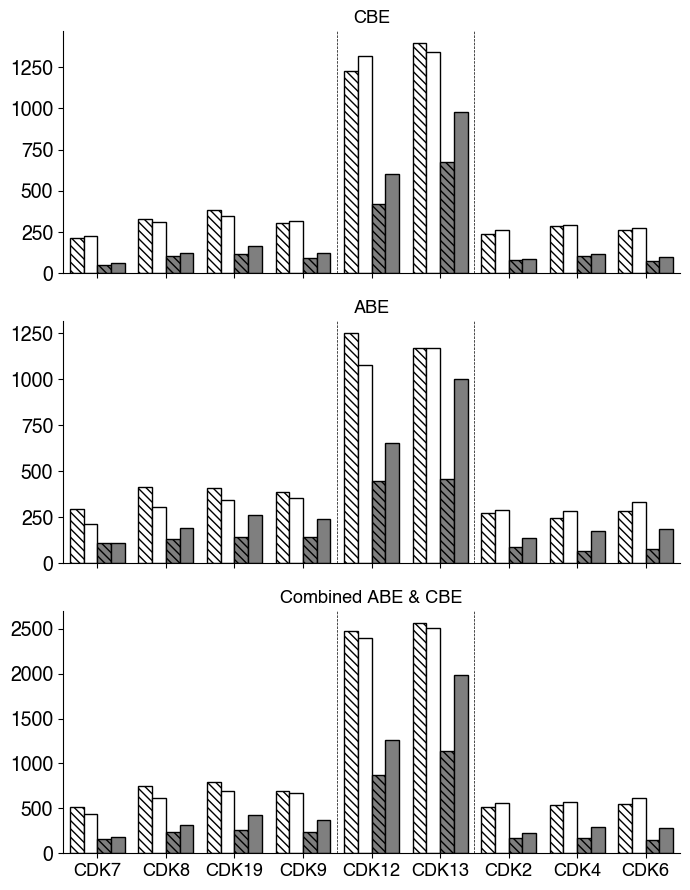

In [137]:
fig, ax = plt.subplots(3,1,figsize=(7,9), sharex=True)
palette = ['white','white','tab:grey','tab:grey',]

ho = ['Predicted Single Mutants', 'Observed Single Mutants', 'Predicted Compound Mutants', 'Observed Compound Mutants']
e = sns.barplot(data=CBE_c, x='Gene', y='value', hue='variable', hue_order = ho, ax=ax[0], palette=palette, edgecolor='black', linewidth=1, legend=False)
f = sns.barplot(data=ABE_c, x='Gene', y='value', hue='variable', hue_order = ho, ax=ax[1], palette=palette, edgecolor='black', linewidth=1, legend=False)
g = sns.barplot(data=Combined_c, x='Gene', y='value', hue='variable', hue_order = ho, ax=ax[2], palette=palette, edgecolor='black', linewidth=1, legend=False)

hatches = ['\\','','\\','','\\',]

for hatch_pattern, these_bars in zip(hatches, e.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(4 * hatch_pattern)

for hatch_pattern, these_bars in zip(hatches, f.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(4 * hatch_pattern)

for hatch_pattern, these_bars in zip(hatches, g.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(4 * hatch_pattern)

ax[0].set_title('CBE', fontsize=13)
ax[1].set_title('ABE', fontsize=13)
ax[2].set_title('Combined ABE & CBE', fontsize=13)

for i in range(3):
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].tick_params(axis='y', which='major', labelsize=14)
    ax[i].tick_params(axis='x', which='major', labelsize=13)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

    ax[i].axvline(3.5, linestyle='dashed', color='black', linewidth=0.5)
    ax[i].axvline(5.5, linestyle='dashed', color='black', linewidth=0.5)


fig.tight_layout()
#fig.savefig('../../figures/compound_single_pred.pdf', transparent=True)